In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os

# CPU fallback (if GPU is not available)
if 'JAX_PLATFORMS' not in os.environ:
    try:
        from jax import devices
        if not any(d.platform == 'gpu' for d in devices()):
            os.environ['JAX_PLATFORMS'] = 'cpu'
    except Exception:
        os.environ['JAX_PLATFORMS'] = 'cpu'

# Import necessary librariesimport jax.nnx as nnx
import jax
import jax.numpy as jnp
import jax.random as random
import optax
from tqdm import tqdm
from utils import DataLoader, MLP, train_step, evaluation_step, MLP_trial
from flax import nnx
from flax.nnx.training.metrics import Metric, Average
import optax
import matplotlib.pyplot as plt

# FIRST TRY: basic linear function

In [5]:
# DATASET GENERATION
key = random.key(0)
#f_to_learn = lambda mu, l, k, x: (mu+l+k)*x
f_to_learn = lambda mu, k, l, x: jnp.sin(2*mu*jnp.pi*x) + k + jnp.exp(-l*x)
#f_to_learn = lambda mu, l, k, x: jnp.exp(-l*x) + mu*x + k*x**2

N = 5000
key, subkey = random.split(key)
x = random.uniform(subkey, (N,), minval=-1, maxval=1)
key, subkey = random.split(key) 
mu = random.uniform(subkey, (N,), minval=1, maxval=1.5)
key, subkey = random.split(key) 
l = random.uniform(subkey, (N,), minval=0, maxval=1)
key, subkey = random.split(key) 
k = random.uniform(subkey, (N,), minval=-2, maxval=2)
y = f_to_learn(mu, l, k, x)
X = jnp.stack([mu, l, k, x], axis=1)

# DATASET SPLIT AND DATALOADER
split_idx = int(N * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
train_dataloader = DataLoader(X_train, y_train, batch_size=8, shuffle=True)
test_dataloader = DataLoader(X_test, y_test, batch_size=8, shuffle=False)

In [6]:
# FOR NOW: TARGET NETWORK WITH KNOWN FIXED NUMBER OF PARAMETERS
num_params = 97
#num_params = 25
#num_params = 33
hypernetwork = MLP_trial(input_dim=3, output_dim=num_params, hidden_dim1=32, hidden_dim2=128, num_hidden_layers1=2, num_hidden_layers2=1, rngs=nnx.Rngs(0))
#hypernetwork = MLP(input_dim=3, output_dim=num_params, hidden_dim = 64, num_hidden_layers=1, rngs=nnx.Rngs(0))

optimizer = nnx.Optimizer(hypernetwork, optax.adam(learning_rate=1e-5))
training_loss = Average(argname='loss')
test_loss = Average(argname='loss')
epochs = 100
pbar = tqdm(range(epochs))
for epoch in pbar:
    pbar.set_description(f"Epoch {epoch+1}")
    training_loss.reset()
    test_loss.reset()
    for data, label in train_dataloader:
        hyperparams = data[:, :-1] # mu, l, k
        x = data[:, -1:] # x
        loss_step = train_step(hypernetwork, MLP, hyperparams, x, label, optimizer, x.shape[0])
        training_loss.update(loss = loss_step.item()) #TODO: CONTROLLARE SE FUNZIONA (IN PARTICOLARE SE TIENE CONTO CHE L'ULTIMO BATCH POTREEBBE ESSERE PIU' PICCOLO)
    for data, label in test_dataloader:
        hyperparams = data[:, :-1]
        x = data[:, -1:]
        loss_step = evaluation_step(hypernetwork, MLP, hyperparams, x, label, x.shape[0])
        test_loss.update(loss = loss_step.item())
    pbar.set_postfix({"training loss": training_loss.compute(), "test loss": test_loss.compute()})

Epoch 100: 100%|██████████| 100/100 [05:51<00:00,  3.52s/it, training loss=0.07014564, test loss=0.0803789] 


# PROVA CODICE NUOVO

In [ ]:
# Creazioine batch di modelli
batch_size = 4

@nnx.jit
@nnx.split_rngs(splits=batch_size)
@nnx.vmap
def make_model(rngs):
  return MLP(1, 1, 8, 0, rngs=rngs)

model = make_model(nnx.Rngs(0))

print(model)
x = jnp.array([[2], [0], [2], [2]])

model(x) # MA QUESTO NON FA QUELLO CHE DEVE FARE! NO?

MLP( # Param: 8 (32 B)
  layers=Sequential( # Param: 8 (32 B)
    layers=[Linear( # Param: 8 (32 B)
      bias=Param( # 4 (16 B)
        value=Array(shape=(4, 1), dtype=dtype('float32'))
      ),
      bias_init=<function zeros at 0x753e1f3302c0>,
      dot_general=<function dot_general at 0x753e1fbdc900>,
      dtype=None,
      in_features=1,
      kernel=Param( # 4 (16 B)
        value=Array(shape=(4, 1, 1), dtype=dtype('float32'))
      ),
      kernel_init=<function variance_scaling.<locals>.init at 0x753d98503100>,
      out_features=1,
      param_dtype=float32,
      precision=None,
      promote_dtype=<function promote_dtype at 0x753d98503380>,
      use_bias=True
    )]
  ),
  num_hidden_layers=0
)


TypeError: dot_general requires contracting dimensions to have the same shape, got (1,) and (4,).

In [8]:
# Provo a modificare parametri del batch di modelli con solita funzione

@nnx.vmap
def assign_parameters(state, parameters):
    """
    Assigns the parameters from an array to the state. state and parameters must be batched with the same first dimension.
    """
    parameters = parameters.squeeze()
    flat_state = nnx.to_flat_state(state)

    # TODO: Check if the number of parameters matches
    
    i=0
    for (key, param) in flat_state:
        param.value = parameters[i: i + param.value.size].reshape(param.value.shape)
        i += param.value.size   
    return state


graphdef, state = nnx.split(model)
w = jnp.array([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0], [7.0, 8.0]])

new_state = assign_parameters(state, w)

new_model = nnx.merge(graphdef, new_state)

@nnx.vmap(in_axes=(0, 0), out_axes=0)
def apply_batch(model, x):
    return model(x)

#new_model(jnp.array([[1], [2], [3], [4]]))  # NON SI PUO' USARE COSì, DEVO USARE APPLY_BATCH

y = apply_batch(new_model, jnp.array([[1], [2], [3], [4]]))  # Test the new model with some input
print(y)

# Nel codice sopra, applichiamo modello dentro funzione vmappata (funzione apply), quindi perfetto

[[ 3.]
 [11.]
 [23.]
 [39.]]


# BAD RESULT

This is wrong: every model receive the entire array [1,2,3,4] due to JAX's broadcasting rules.

In [ ]:
@nnx.jit
@nnx.split_rngs(splits=batch_size)
@nnx.vmap
def make_model(rngs):
  return MLP(1, 1, 8, 0, rngs=rngs)

models = make_model(nnx.Rngs(0))

models(jnp.array([1,2,3,4]))  # Test the new model with some input

Array([[61., 63., 65., 67.]], dtype=float32)

we need instead to do:

In [ ]:
# Reshape inputs to (4,1) for 4 models with input_dim=1
inputs = jnp.array([[1.0], [2.0], [3.0], [4.0]])

# Apply each input to corresponding model
@nnx.vmap(in_axes=(0, 0), out_axes=0)
def apply_individual(model, x):
    return model(x)

result = apply_individual(models, inputs)

# GRAFICI

In [ ]:
from utils import apply
import numpy as np
N = 1
key = random.key(100) #NON METTERE 0 SE NO è DATA LEAKING
key, subkey = random.split(key) 
mu = random.uniform(subkey, (N,), minval=-2, maxval=2)
key, subkey = random.split(key)
l = random.uniform(subkey, (N,), minval=0, maxval=1)
key, subkey = random.split(key) 
k = random.uniform(subkey, (N,), minval=-2, maxval=2)

h = jnp.stack([mu, l, k], axis=1)

x_vector = jnp.linspace(-1, 1, 101)
pred_vector = np.zeros(x_vector.shape)
y_vector = jnp.array([f_to_learn(mu, k, l, x) for x in x_vector])
w = hypernetwork(h) #USARE HYPERNETWORK GIA TRAINATA

@nnx.split_rngs(splits=1)
@nnx.vmap(in_axes=(0, None), out_axes=0)
def make_model(rngs, targetnetwork_fun):
    return targetnetwork_fun(1, 1, 8, 1, rngs=rngs)

for i in range(len(x_vector)):      
    x = jnp.array([[x_vector[i].item()]])
    target_network = make_model(nnx.Rngs(0), MLP)
    pred_vector[i] = apply(target_network, w, x).item()


In [ ]:
np.mean((y_vector.squeeze() - pred_vector.squeeze())**2) #STRANO PERCHE MOLTO DISTANTE DA QUELLA DELL'EVALUATION

Array(7.425038, dtype=float32)

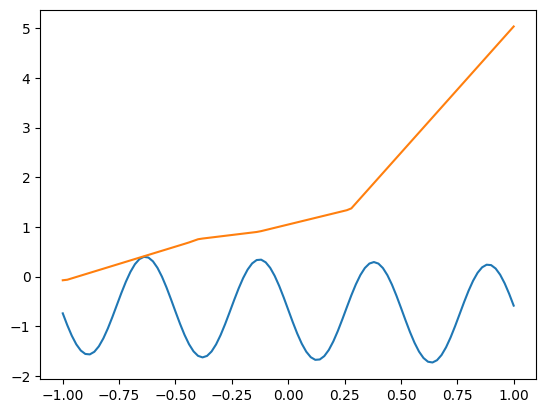

In [78]:
import matplotlib.pyplot as plt
plt.plot(x_vector, y_vector, x_vector, pred_vector)

# COSE CHE SAREBBE UTILE AVERE:
* Modo per creare facilmente una target network dati i parametri, per poi applicarla (anzichè usare ogni volta apply)
* Modi per valutare diverse network sullo stesso input e viceversa (diversi input sulla stessa network, che in teoria c'è di base)

# RIPROVA GRAFICI

In [7]:
import numpy as np

# Fissa mu,l,k e vedi se riesci a ricostruire funzione
N = 1
key = random.key(1000) #NON METTERE 0 SE NO è DATA LEAKING
key, subkey = random.split(key) 
mu = random.uniform(subkey, (N,), minval=1, maxval=1.5)
key, subkey = random.split(key)
l = random.uniform(subkey, (N,), minval=0, maxval=1)
key, subkey = random.split(key) 
k = random.uniform(subkey, (N,), minval=-2, maxval=2)

h = jnp.stack([mu, l, k], axis=1)

x_vector = jnp.linspace(-1, 1, 101)
x_vector = x_vector[:,None]

#pred_vector = jnp.zeros(x_vector.shape)
y_vector = jnp.array([f_to_learn(mu, l, k, x) for x in x_vector])
w = hypernetwork(h) #USARE HYPERNETWORK GIA TRAINATA

In [8]:
targetnetwork = MLP(input_dim=1, output_dim=1, hidden_dim=8, num_hidden_layers=2, rngs=nnx.Rngs(0))

# Load weights from hypernet
parameters = w.squeeze()
_, state = nnx.split(targetnetwork)
flat_state = nnx.to_flat_state(state)

# TODO: Check if the number of parameters matches

i = 0
for key, param in flat_state:
    param_size = param.value.size
    # Extract parameters for this specific parameter
    param_values = parameters[i:i + param_size]
    # Reshape to match the original parameter shape
    param.value = param_values.reshape(param.value.shape)
    i += param_size

nnx.update(targetnetwork, state)

# Compute predictions
y_pred = targetnetwork(x_vector)

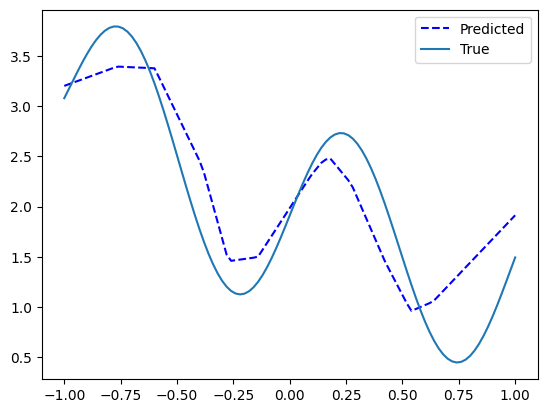

In [9]:
plt.figure()
plt.plot(x_vector, y_pred, '--b')
plt.plot(x_vector, y_vector)
plt.legend(['Predicted', 'True'])